# **2D spatial understanding with Gemini 2.0( Gemini 2.0 2D공간이해)**


## **[참고] cookbook/quickstarts/**Spatial_understanding**.ipynb**
- https://github.com/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb
- https://github.com/google-gemini/cookbook/tree/main/quickstarts



## object detection에 포함된 내역
- simply overlaying information
- searching within an image
- translating and understanding things in multiple languages
- using Gemini thinking abilities



---



## **Setup**

### Install SDK

In [ ]:
%pip install -U -q "google-genai>=1.16.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 20.7 MB/s eta 0:00:00


### Setup your API key
- GEMINI_API_KEY or GOOGLE_API_KEY ⮕ 이미 키가 둘다 존재하는 경우 (**GOOGLE_API_KEY** > GEMINI_API_KEY)
- **API 키 만들기(Gemini API Key)** : https://aistudio.google.com/app/apikey?hl=ko
- **Authentication** 코랩 왼쪽 메뉴(보안 비밀 아이콘) 클릭하여 노트북 액세스용 API Key 설정하기
    - https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb

In [ ]:
from google.colab import userdata
import os

os.environ['GEMINI_API_KEY'] = "YOUR API KEY"
GEMINI_API_KEY = "YOUR API KEY"
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

- Old 모델 사용 (예시: gemini-1.5-flash-001)

In [ ]:
model_name = "gemini-2.5-flash-preview-05-20" # @param ["gemini-1.5-flash-latest","gemini-2.0-flash-lite","gemini-2.0-flash","gemini-2.5-flash-preview-05-20","gemini-2.5-pro-preview-06-05"] {"allow-input":true}


### System instructions
system_instructions 및 모델 매개변수를 모든 generate_content 호출에 전달할 때 항상 입력하지 않아도 되도록 이를 지정한다.

In [ ]:
bounding_box_system_instructions = """
    Return bounding boxes as a JSON array with labels. Never return masks or code fencing. Limit to 25 objects.
    If an object is present multiple times, name them according to their unique characteristic (colors, size, position, unique characteristics, etc..).
      """


In [ ]:
safety_settings = [
    types.SafetySetting(
        category="HARM_CATEGORY_DANGEROUS_CONTENT",
        threshold="BLOCK_ONLY_HIGH",
    ),
]

In [ ]:
import google.generativeai as genai
from PIL import Image

import io
import os
import requests
from io import BytesIO

In [ ]:
# @title Parsing JSON output
def parse_json(json_output: str):
    # Parsing out the markdown fencing
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line == "```json":
            json_output = "\n".join(lines[i+1:])  # Remove everything before "```json"
            json_output = json_output.split("```")[0]  # Remove everything after the closing "```"
            break  # Exit the loop once "```json" is found
    return json_output


# @title Plotting Util

# Get Noto JP font to display janapese characters
!apt-get install fonts-noto-cjk  # For Noto Sans CJK JP

#!apt-get install fonts-source-han-sans-jp # For Source Han Sans (Japanese)

import json
import random
import io
from PIL import Image, ImageDraw, ImageFont
from PIL import ImageColor

additional_colors = [colorname for (colorname, colorcode) in ImageColor.colormap.items()]

def plot_bounding_boxes(im, bounding_boxes):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img_path: The path to the image file.
        bounding_boxes: A list of bounding boxes containing the name of the object
         and their positions in normalized [y1 x1 y2 x2] format.
    """

    # Load the image
    img = im
    width, height = img.size
    print(img.size)
    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors

    # Parsing out the markdown fencing
    bounding_boxes = parse_json(bounding_boxes)

    font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

    # Iterate over the bounding boxes
    for i, bounding_box in enumerate(json.loads(bounding_boxes)):
      # Select a color from the list
      color = colors[i % len(colors)]

      # Convert normalized coordinates to absolute coordinates
      abs_y1 = int(bounding_box["box_2d"][0]/1000 * height)
      abs_x1 = int(bounding_box["box_2d"][1]/1000 * width)
      abs_y2 = int(bounding_box["box_2d"][2]/1000 * height)
      abs_x2 = int(bounding_box["box_2d"][3]/1000 * width)

      if abs_x1 > abs_x2:
        abs_x1, abs_x2 = abs_x2, abs_x1

      if abs_y1 > abs_y2:
        abs_y1, abs_y2 = abs_y2, abs_y1

      # Draw the bounding box
      draw.rectangle(
          ((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4
      )

      # Draw the text
      if "label" in bounding_box:
        draw.text((abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font)

    # Display the image
    img.show()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


### Get example images

In [ ]:
# Load sample images
!wget https://storage.googleapis.com/generativeai-downloads/images/socks.jpg -O Socks.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/vegetables.jpg -O Vegetables.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/Japanese_Bento.png -O Japanese_bento.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/Cupcakes.jpg -O Cupcakes.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/origamis.jpg -O Origamis.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/fruits.jpg -O Fruits.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/cat.jpg -O Cat.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/pumpkins.jpg -O Pumpkins.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/breakfast.jpg -O Breakfast.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/bookshelf.jpg -O Bookshelf.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/spill.jpg -O Spill.jpg -q


## **Overlaying Information**
(기존 정보 위에 추가적인 정보를 겹쳐서 표시)

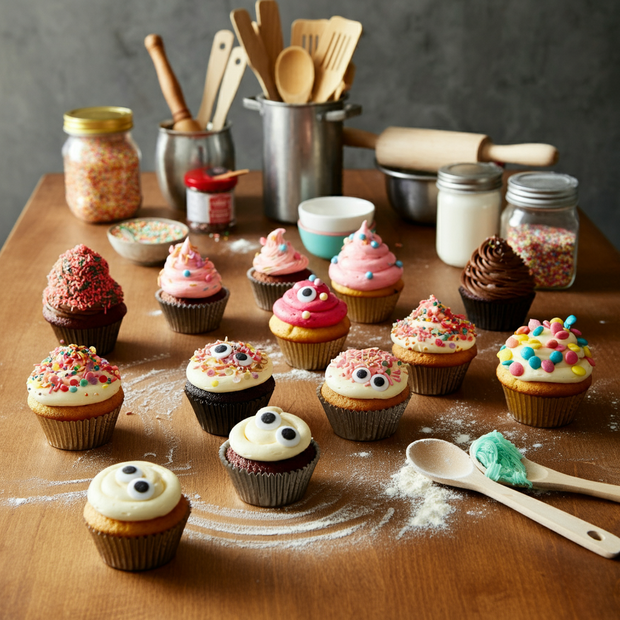

In [ ]:
image = "Cupcakes.jpg" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg","koreanfood_menu.png"] {"allow-input":true}

im = Image.open(image)
im.thumbnail([620,620], Image.Resampling.LANCZOS)
im

In [ ]:
prompt = "Detect the 2d bounding boxes of the cupcakes (with “label” as topping description”)"  # @param {type:"string"}


# Load and resize image
im = Image.open(BytesIO(open(image, "rb").read()))
im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Check output
print(response.text)


```json
[
  {"box_2d": [390, 62, 563, 203], "label": "cupcake with pink and red sprinkles"},
  {"box_2d": [380, 247, 532, 369], "label": "cupcake with pink frosting and small blue and pink sprinkles"},
  {"box_2d": [363, 396, 497, 502], "label": "cupcake with light pink frosting and small white sprinkles"},
  {"box_2d": [351, 528, 517, 650], "label": "cupcake with pink frosting and blue sprinkles"},
  {"box_2d": [381, 735, 529, 863], "label": "cupcake with chocolate frosting"},
  {"box_2d": [438, 431, 588, 564], "label": "cupcake with pink frosting and candy eyes"},
  {"box_2d": [471, 623, 631, 767], "label": "cupcake with white frosting and colorful sprinkles"},
  {"box_2d": [506, 792, 680, 951], "label": "cupcake with white frosting and colorful candy"},
  {"box_2d": [549, 39, 715, 198], "label": "cupcake with white frosting and colorful sprinkles"},
  {"box_2d": [542, 292, 690, 442], "label": "cupcake with white frosting, candy eyes, and yellow sprinkles"},
  {"box_2d": [556, 510, 7

(1024, 1024)


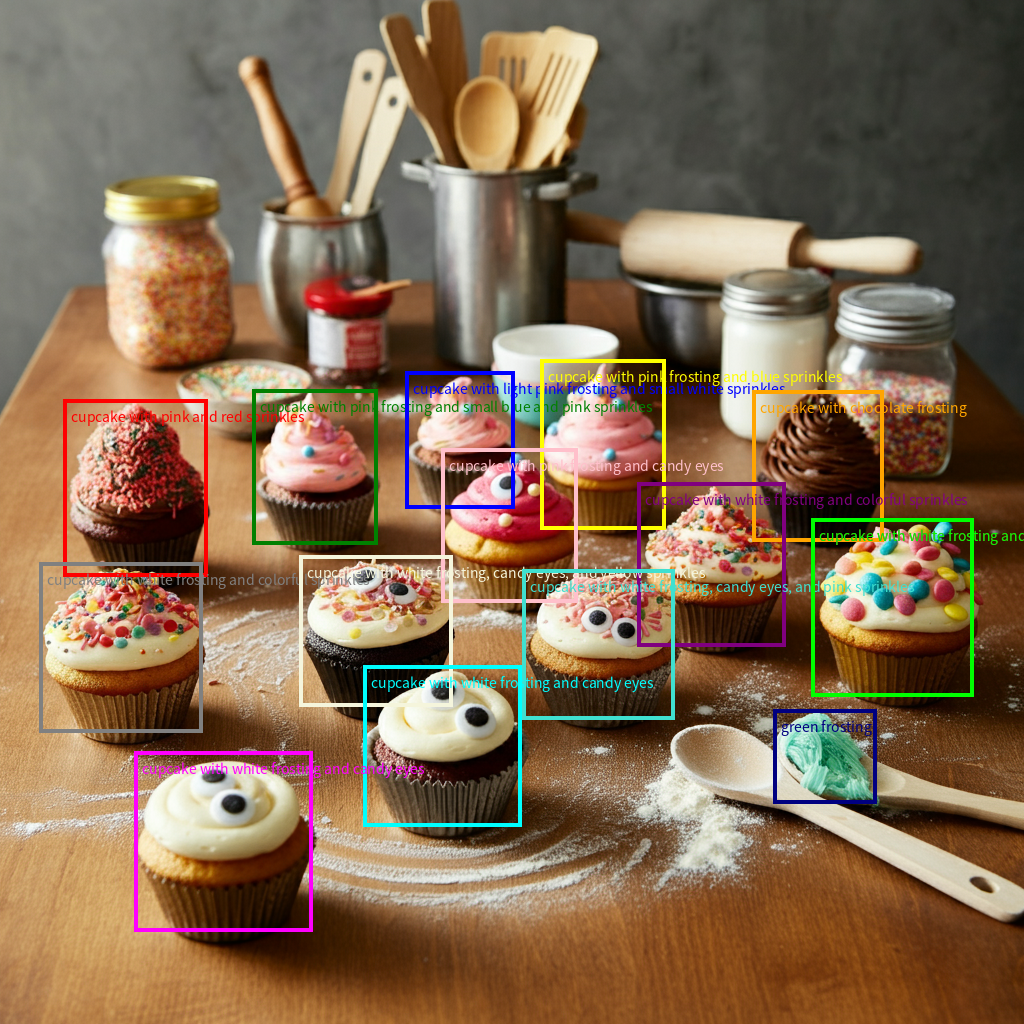

In [ ]:

plot_bounding_boxes(im, response.text)
im

## **Search within an image (이미지 내에서 검색)**

```json
[
  {"box_2d": [53, 248, 386, 526], "label": "the socks with the face"},
  {"box_2d": [236, 663, 652, 863], "label": "the socks with the face"}
]
```
(640, 482)


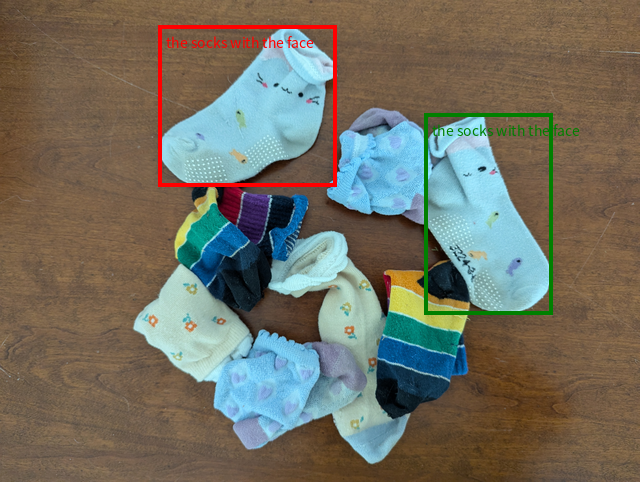

In [ ]:
image = "Socks.jpg" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg"] {"allow-input":true}
prompt = "Show me the positions of the socks with the face"  # @param ["Detect all rainbow socks", "Find all socks and label them with emojis ", "Show me the positions of the socks with the face","Find the sock that goes with the one at the top"] {"allow-input":true}

# Load and resize image
im = Image.open(image)
im.thumbnail([640,640], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Check output
print(response.text)

# Generate image with bounding boxes
plot_bounding_boxes(im, response.text)
im

##  **Multilinguality(다국어 번역/표시)**

(640, 640)


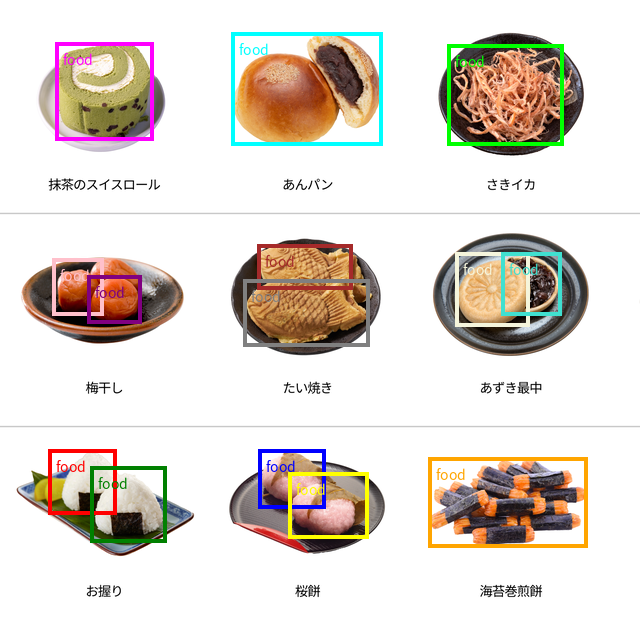

In [ ]:
image = "Japanese_bento.png" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg"] {"allow-input":true}
prompt = "Detect food, label them with Japanese characters + english translation."  # @param ["Detect food, label them with Japanese characters + english translation.", "Show me the vegan dishes","Explain what those dishes are with a 5 words description","Find the dishes with allergens and label them accordingly"] {"allow-input":true}

#image = "koreanfood_menu.png" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg", "koreanfood_menu.png"] {"allow-input":true}
#prompt = "Detect food, label them with Koreab characters + english translation."  # @param ["Detect food, label them with Korean characters + english translation.", "Show me the fork dishes","Explain what those dishes are with a 5 words description","Find the dishes with allergens and label them accordingly"] {"allow-input":true}


# Load and resize image
im = Image.open(image)
im.thumbnail([640,640], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Generate image with bounding boxes
plot_bounding_boxes(im, response.text)
im

### [실습] 한국어 음식 메뉴 표시하기
한국어 음식 메뉴판 사진을 업로드하고, 음식을 감지한후(boundingbox) 한글 메뉴글자를 표시하기  

(422, 640)


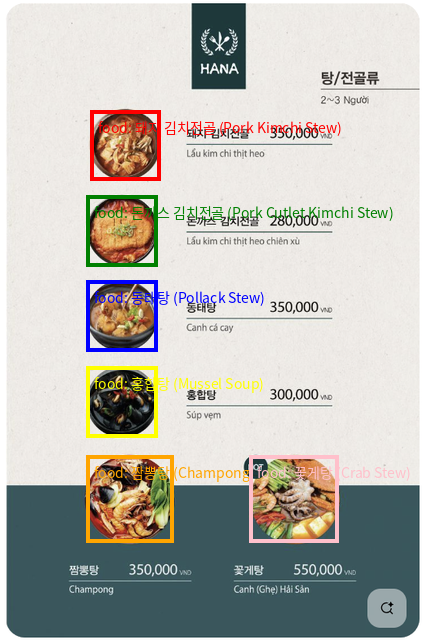

In [ ]:
image = "koreanfood_menu.png" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg", "koreanfood_menu.png"] {"allow-input":true}
prompt = "Detect food, label them with Koreab characters + english translation."  # @param ["Detect food, label them with Korean characters + english translation.", "Show me the fork dishes","Explain what those dishes are with a 5 words description","Find the dishes with allergens and label them accordingly"] {"allow-input":true}


# Load and resize image
im = Image.open(image)
im.thumbnail([640,640], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Generate image with bounding boxes
plot_bounding_boxes(im, response.text)
im

## **Use Gemini reasoning capabilities(Gemini 추론 능력 활용)**

(640, 482)


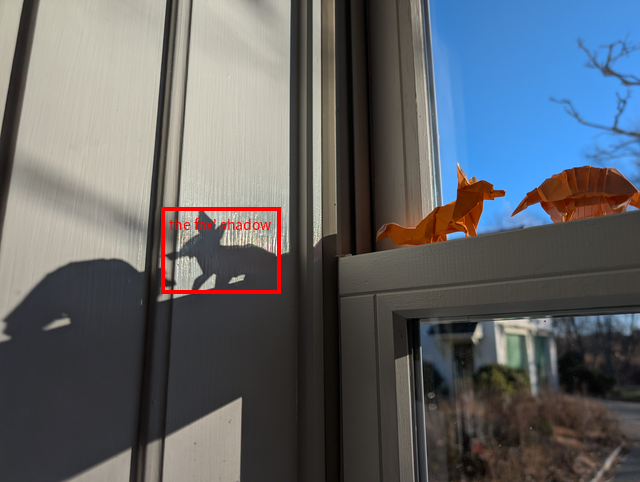

In [ ]:
image = "Origamis.jpg" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg"] {"allow-input":true}
prompt = "Draw a square around the fox' shadow"  # @param ["Find the two origami animals.", "Where are the origamis' shadows?","Draw a square around the fox' shadow"] {"allow-input":true}

# Load and resize image
im = Image.open(image)
im.thumbnail([640,640], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Generate image with bounding boxes
plot_bounding_boxes(im, response.text)
im

(640, 480)


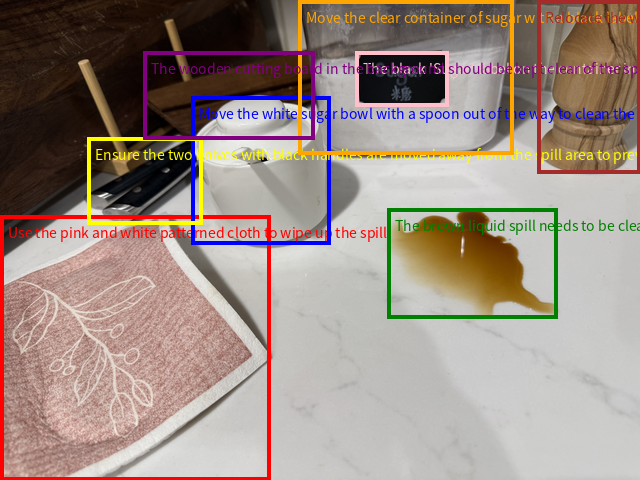

In [ ]:
image = "Spill.jpg" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg"] {"allow-input":true}
prompt = "Tell me how to clean my table with an explanation as label. Do not just label the items"  # @param ["Show me where my coffee was spilled.", "Tell me how to clean my table with an explanation as label. Do not just label the items","Draw a square around the fox' shadow"] {"allow-input":true}

# Load and resize image
im = Image.open(image)
im.thumbnail([640,640], Image.Resampling.LANCZOS)

# Run model to find bounding boxes
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        system_instruction=bounding_box_system_instructions,
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Generate image with bounding boxes
plot_bounding_boxes(im, response.text)
im


In [ ]:
response.text

'```json\n[\n  {"box_2d": [448, 0, 1000, 423], "label": "Use the pink and white patterned cloth to wipe up the spill."},\n  {"box_2d": [435, 606, 664, 871], "label": "The brown liquid spill needs to be cleaned up from the white countertop."},\n  {"box_2d": [200, 299, 510, 517], "label": "Move the white sugar bowl with a spoon out of the way to clean the spill."},\n  {"box_2d": [287, 137, 467, 316], "label": "Ensure the two knives with black handles are moved away from the spill area to prevent contamination or accidents."},\n  {"box_2d": [0, 467, 321, 803], "label": "Move the clear container of sugar with a black label to a safe, dry place away from the spill."},\n  {"box_2d": [107, 555, 221, 700], "label": "The black \'Sugar\' label on the container indicates its contents, which should be kept dry."},\n  {"box_2d": [107, 224, 291, 492], "label": "The wooden cutting board in the background should be kept clear of the spill."},\n  {"box_2d": [0, 840, 362, 1000], "label": "Relocate the w

---
## **Experimental: Segmentation (세그멘테이션)**
---

In [ ]:
# @title Segmentation Utils

import dataclasses
import numpy as np
import base64

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
  # bounding box pixel coordinates (not normalized)
  y0: int # in [0..height - 1]
  x0: int # in [0..width - 1]
  y1: int # in [0..height - 1]
  x1: int # in [0..width - 1]
  mask: np.array # [img_height, img_width] with values 0..255
  label: str

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
  items = json.loads(parse_json(predicted_str))
  masks = []
  for item in items:
    raw_box = item["box_2d"]
    abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
    abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
    abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
    abs_x1 = int(item["box_2d"][3] / 1000 * img_width)
    if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
      print("Invalid bounding box", item["box_2d"])
      continue
    label = item["label"]
    png_str = item["mask"]
    if not png_str.startswith("data:image/png;base64,"):
      print("Invalid mask")
      continue
    png_str = png_str.removeprefix("data:image/png;base64,")
    png_str = base64.b64decode(png_str)
    mask = Image.open(io.BytesIO(png_str))
    bbox_height = abs_y1 - abs_y0
    bbox_width = abs_x1 - abs_x0
    if bbox_height < 1 or bbox_width < 1:
      print("Invalid bounding box")
      continue
    mask = mask.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
    np_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    np_mask[abs_y0:abs_y1, abs_x0:abs_x1] = mask
    masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, np_mask, label))
  return masks

def overlay_mask_on_img(
    img: Image,
    mask: np.ndarray,
    color: str,
    alpha: float = 0.7
) -> Image.Image:
    """
    Overlays a single mask onto a PIL Image using a named color.

    The mask image defines the area to be colored. Non-zero pixels in the
    mask image are considered part of the area to overlay.

    Args:
        img: The base PIL Image object.
        mask: A PIL Image object representing the mask.
              Should have the same height and width as the img.
              Modes '1' (binary) or 'L' (grayscale) are typical, where
              non-zero pixels indicate the masked area.
        color: A standard color name string (e.g., 'red', 'blue', 'yellow').
        alpha: The alpha transparency level for the overlay (0.0 fully
               transparent, 1.0 fully opaque). Default is 0.7 (70%).

    Returns:
        A new PIL Image object (in RGBA mode) with the mask overlaid.

    Raises:
        ValueError: If color name is invalid, mask dimensions mismatch img
                    dimensions, or alpha is outside the 0.0-1.0 range.
    """
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("Alpha must be between 0.0 and 1.0")

    # Convert the color name string to an RGB tuple
    try:
        color_rgb: Tuple[int, int, int] = ImageColor.getrgb(color)
    except ValueError as e:
        # Re-raise with a more informative message if color name is invalid
        raise ValueError(f"Invalid color name '{color}'. Supported names are typically HTML/CSS color names. Error: {e}")

    # Prepare the base image for alpha compositing
    img_rgba = img.convert("RGBA")
    width, height = img_rgba.size

    # Create the colored overlay layer
    # Calculate the RGBA tuple for the overlay color
    alpha_int = int(alpha * 255)
    overlay_color_rgba = color_rgb + (alpha_int,)

    # Create an RGBA layer (all zeros = transparent black)
    colored_mask_layer_np = np.zeros((height, width, 4), dtype=np.uint8)

    # Mask has values between 0 and 255, threshold at 127 to get binary mask.
    mask_np_logical = mask > 127

    # Apply the overlay color RGBA tuple where the mask is True
    colored_mask_layer_np[mask_np_logical] = overlay_color_rgba

    # Convert the NumPy layer back to a PIL Image
    colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')

    # Composite the colored mask layer onto the base image
    result_img = Image.alpha_composite(img_rgba, colored_mask_layer_pil)

    return result_img

def plot_segmentation_masks(img: Image, segmentation_masks: list[SegmentationMask]):
    """
    Plots bounding boxes on an image with markers for each a name, using PIL, normalized coordinates, and different colors.

    Args:
        img: The PIL.Image.
        segmentation_masks: A string encoding as JSON a list of segmentation masks containing the name of the object,
         their positions in normalized [y1 x1 y2 x2] format, and the png encoded segmentation mask.
    """
    # Define a list of colors
    colors = [
    'red',
    'green',
    'blue',
    'yellow',
    'orange',
    'pink',
    'purple',
    'brown',
    'gray',
    'beige',
    'turquoise',
    'cyan',
    'magenta',
    'lime',
    'navy',
    'maroon',
    'teal',
    'olive',
    'coral',
    'lavender',
    'violet',
    'gold',
    'silver',
    ] + additional_colors
    font = ImageFont.truetype("NotoSansCJK-Regular.ttc", size=14)

    # Do this in 3 passes to make sure the boxes and text are always visible.

    # Overlay the mask
    for i, mask in enumerate(segmentation_masks):
      color = colors[i % len(colors)]
      img = overlay_mask_on_img(img, mask.mask, color)

    # Create a drawing object
    draw = ImageDraw.Draw(img)

    # Draw the bounding boxes
    for i, mask in enumerate(segmentation_masks):
      color = colors[i % len(colors)]
      draw.rectangle(
          ((mask.x0, mask.y0), (mask.x1, mask.y1)), outline=color, width=4
      )

    # Draw the text labels
    for i, mask in enumerate(segmentation_masks):
      color = colors[i % len(colors)]
      if mask.label != "":
        draw.text((mask.x0 + 8, mask.y0 - 20), mask.label, fill=color, font=font)
    return img

```json
[
  {"box_2d": [190, 252, 342, 381], "mask": "", "label": "metal item"},
  {"box_2d": [262, 617, 368, 708], "mask": "", "label": "metal item"},
  {"box_2d": [145, 391, 362, 584], "mask": "", "label": "metal item"},
  {"box_2d": [277, 804, 467, 936], "mask": "", "label": "glass item"},
  {"box_2d": [261, 703, 431, 810], "mask": "", "label": "glass item"},
  {"box_2d": [170, 97, 362, 230], "mask": "", "label": "glass item"},
  {"box_2d": [200, 552, 277, 897], "mask": "", "label": "wooden item"},
  {"box_2d": [706, 655, 902, 1000], "mask": "", "label": "wooden item"},
  {"box_2d": [689, 747, 810, 1000], "mask": "", "label": "wooden item"}
]
```

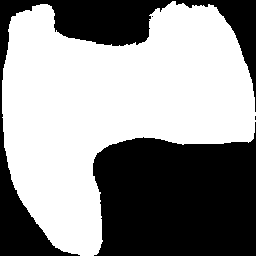
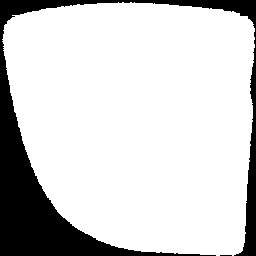
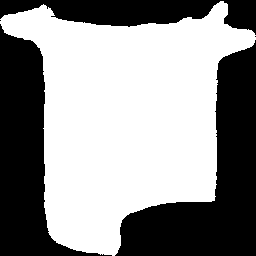
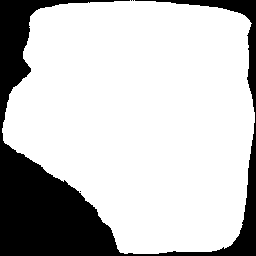
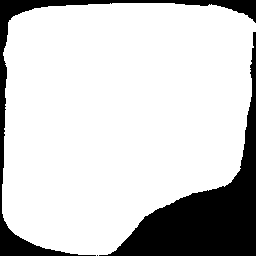
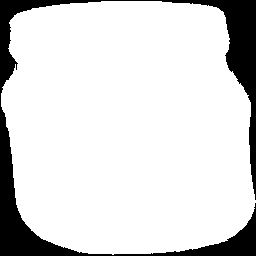
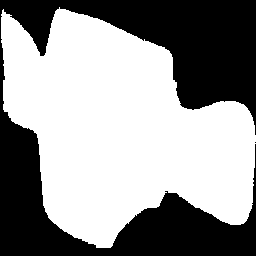
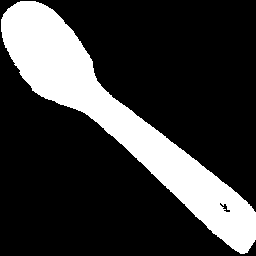
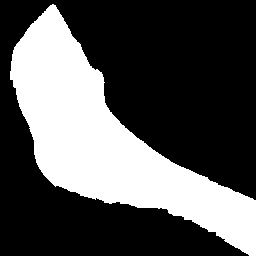

In [ ]:
image = "Cupcakes.jpg" # @param ["Socks.jpg","Vegetables.jpg","Japanese_bento.png","Cupcakes.jpg","Origamis.jpg","Fruits.jpg","Cat.jpg","Pumpkins.jpg","Breakfast.jpg","Bookshelf.jpg", "Spill.jpg"] {"allow-input":true}
prompt = "Give the segmentation masks for the metal, wooden and glass small items (ignore the table). Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key \"box_2d\", the segmentation mask in key \"mask\", and the text label in the key \"label\". Use descriptive labels."  # @param {type:"string"}

# Load and resize image
im = Image.open(BytesIO(open(image, "rb").read()))
im.thumbnail([1024,1024], Image.Resampling.LANCZOS)

# Run model to find segmentation masks
response = client.models.generate_content(
    model=model_name,
    contents=[prompt, im],
    config = types.GenerateContentConfig(
        temperature=0.5,
        safety_settings=safety_settings,
        thinking_config=types.ThinkingConfig(
          thinking_budget=0
        )
    )
)

# Check output
print(response.text)


In [ ]:
segmentation_masks = parse_segmentation_masks(response.text, img_height=im.size[1], img_width=im.size[0])


In [ ]:
plot_segmentation_masks(im, segmentation_masks)

Output hidden; open in https://colab.research.google.com to view.



---



### [미션] Google Geminicookbook/quickstarts 수행하기
Google Geminicookbook/quickstarts 에 있는 노트북 코드파일 2개를 선택하고  노트북 맨 위에 선택 이유를 셀에 작성하고, 내용을 모두 실행한후 실행된 (코랩)결과를 제출하시오.



- 1번 노트북에 포함될 내용(각 파일 맨 앞에 작성)
    - 한글제목:
    - 파일명:(~.ipynb)
    - 선택이유:
- 2번 노트북에 포함될 내용(각 파일 맨 앞에 작성)
    - 한글제목:
    - 파일명:(~.ipynb)
    - 선택이유: